# Интеллектуальный анализ данных – весна 2025
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [102]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [103]:
df = pd.read_csv('tweets_coronavirus.csv', encoding='latin-1')
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [104]:
# -- YOUR CODE HERE --
df['Sentiment'] = df['Sentiment'].apply(lambda x: int(x in ('Positive', 'Extremely Positive')))
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,1
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,1
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,1


Сбалансированы ли классы?

In [105]:
# -- YOUR CODE HERE --
vc = df['Sentiment'].value_counts()
vc
n_pos, n_neg, sm = vc[1], vc[0], vc[1] + vc[0]
print(n_pos, n_neg)
print(round(n_pos / sm, 3), round(n_neg / sm, 3)) # 0.54, 0.46 => balanced

18046 15398
0.54 0.46


**Ответ:** # -- YOUR ANSWER HERE --

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [106]:
# -- YOUR CODE HERE --
df.isna().sum()

UserName            0
ScreenName          0
Location         7049
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [107]:
df.fillna('Unknown', inplace=True)

Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [119]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=0)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [120]:
token_to_freq = {}
for tweet in train['OriginalTweet']:
  tokens = tweet.split()
  for token in tokens:
    token = token.lower()
    if token not in token_to_freq:
      token_to_freq[token] = 1
    else:
      token_to_freq[token] += 1
token_to_freq_sorted = sorted(token_to_freq.items(), key=lambda x: x[1], reverse=True)

Какой размер словаря получился?

In [121]:
print(len(token_to_freq))

79755


Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [122]:
token_to_freq_sorted[:10]

[('the', 26815),
 ('to', 23373),
 ('and', 14684),
 ('of', 13012),
 ('a', 11737),
 ('in', 11198),
 ('for', 8566),
 ('#coronavirus', 8223),
 ('is', 7383),
 ('are', 7050)]

**Ответ:** # артикли - самые частоупотребляемые слова, как будто бы это очевидно. коронавирус попал сюда из-за специфики датасета. 

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [123]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
token_to_freq_wo_stopwords = token_to_freq.copy()
for word in stopwords.words('english'):
    token_to_freq_wo_stopwords.pop(word, None)
token_to_freq_sorted = sorted(token_to_freq_wo_stopwords.items(), key=lambda x: x[1], reverse=True)
token_to_freq_sorted[:10]

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/developer/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('#coronavirus', 8223),
 ('prices', 3891),
 ('food', 3820),
 ('grocery', 3469),
 ('supermarket', 3288),
 ('people', 3175),
 ('covid-19', 3173),
 ('store', 3155),
 ('#covid19', 2471),
 ('&amp;', 2314)]

**Ответ:** лексически простые слова, связанные с покупкой еды (проблема искусственного дефицита во времена коронавируса). 

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [124]:
token_to_freq_sorted[-20:]

[('skellig', 1),
 ('coast!', 1),
 ('closer!)', 1),
 ('@skelligsix18', 1),
 ('#skelligcoast2kms', 1),
 ('#southkerry', 1),
 ('https://t.co/zjcl195vqs', 1),
 ('@srinivasiyc', 1),
 ('https://t.co/iaek4fwsgz', 1),
 ('premiership', 1),
 ('non-playing', 1),
 ('subsidise', 1),
 ('playersã\x82â\x92', 1),
 ('renewing', 1),
 ('wage!', 1),
 ('flew', 1),
 ('nothing...', 1),
 ('@torontopearson', 1),
 ('@680news', 1),
 ('https://t.co/7j2y3rsld9', 1)]

**Ответ:** # Ссылки, сложные термины, кавычки - все это вполне редкие слова. Они могут создавать шум, поэтому можно их и выкинуть, как стоп слова. 



Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [125]:
from nltk.tokenize import TweetTokenizer

token_to_freq_tt = token_to_freq.copy()
tt = TweetTokenizer()
for tweet in train['OriginalTweet']:
  tokens = tt.tokenize(tweet)
  for token in tokens:
    token = token.lower()
    if token not in token_to_freq_tt:
      token_to_freq_tt[token] = 1
    else:
      token_to_freq_tt[token] += 1
token_to_freq_sorted = sorted(token_to_freq_tt.items(), key=lambda x: x[1], reverse=True)
token_to_freq_sorted[:10]

[('the', 53808),
 ('to', 46851),
 ('and', 29509),
 ('of', 26056),
 ('.', 24572),
 ('a', 23628),
 ('in', 22546),
 (',', 17758),
 ('for', 17191),
 ('#coronavirus', 17031)]

**Ответ:** наш прошлый токенайзер различал семантически равные слова типа: 'гойда!' и 'гойда!!!!!!!!!', а новый должен не различать. 

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [127]:
from string import punctuation

nltk.download('stopwords')
token_to_freq_wo_stopwords = token_to_freq_tt.copy()
for word in stopwords.words('english') + list(punctuation):
    token_to_freq_wo_stopwords.pop(word, None)
token_to_freq_sorted = sorted(token_to_freq_wo_stopwords.items(), key=lambda x: x[1], reverse=True)
token_to_freq_sorted[:10]

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/developer/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('#coronavirus', 17031),
 ('19', 9278),
 ('prices', 8492),
 ('food', 8187),
 ('covid', 8022),
 ('â', 7415),
 ('\x82', 7311),
 ('supermarket', 7093),
 ('store', 7032),
 ('grocery', 6992)]

**Ответ:** # спецсимволы остались

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [128]:
token_to_freq_clear = token_to_freq_wo_stopwords.copy()
ks = set(token_to_freq_clear.keys())
for word in ks:
    if len(word) == 1 and ord(word) >= 128:
        token_to_freq_clear.pop(word, None)
token_to_freq_sorted = sorted(token_to_freq_clear.items(), key=lambda x: x[1], reverse=True)
for i in token_to_freq_sorted[:10]:
    print(i)

('#coronavirus', 17031)
('19', 9278)
('prices', 8492)
('food', 8187)
('covid', 8022)
('supermarket', 7093)
('store', 7032)
('grocery', 6992)
('people', 6638)
('#covid19', 5060)


In [129]:
for i in token_to_freq_sorted[-20:]:
    print(i)

('357million', 1)
('@cristina_novop', 1)
('1700', 1)
('covidma', 1)
('commonwealth', 1)
('michiganã', 1)
('#crooks', 1)
('kitã', 1)
('#exponentialgrowth', 1)
('holocaust', 1)
('scratchy', 1)
('frontlineã', 1)
('battlingã', 1)
('housekeepingã', 1)
('gawd', 1)
('@brianstelter', 1)
('@reliablesources', 1)
('lunchboxes', 1)
('vapers', 1)
('playersã', 1)


**Ответ:** # по вкусу и сути топ слова никак не изменились, а вот лоу слова стали выглядеть менее мусорно.

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [130]:
i = 0
for k, v in token_to_freq_sorted:
    if k.startswith('#'):
        i += 1
        print(k, v)
    if i == 10:
        break

#coronavirus 17031
#covid19 5060
#covid_19 3394
#covid2019 1861
#toiletpaper 1435
#socialdistancing 892
#coronacrisis 871
#covid 833
#coronaviruspandemic 494
#pandemic 489


**Ответ:** можно сказать лишь то, что хештеги очень полезны спасибо.

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [131]:
i = 0
for k, v in token_to_freq_sorted:
    if k.startswith('https://t.co'):
        i += 1
        print(k, v)
    if i == 10:
        break

https://t.co/oxa7swtond 10
https://t.co/gp3eusapl8 8
https://t.co/deftrui1pfãâ 6
https://t.co/wrlhyzizaa 6
https://t.co/kuwipf1kqw 6
https://t.co/zjnrx6dkkn 6
https://t.co/3gbbdpdjat 6
https://t.co/e2znxajpre 6
https://t.co/catkegayoy 6
https://t.co/g63rp042ho 6


**Ответ:** # популярность несравнима. скорее всего такая информация полезной не будет из-за того, что ссылка скорее больше походит на мусор

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [132]:
def custom_tokenizer(text):

  tokenizer = TweetTokenizer()
  tokens = tokenizer.tokenize(text)
  tokens = [token.lower() for token in tokens]
  tokens = [token for token in tokens if 
            token not in stopwords.words('english') + list(punctuation) and 
            not (len(token) == 1 and ord(token) >= 128) and
            not token.startswith('https://t.co')]

  return tokens


In [133]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [135]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer, token_pattern=None)

cv.fit_transform(train['OriginalTweet'])

print(len(cv.vocabulary_))

45290


**Ответ:** уменьшился почти в 2 раза.

Посмотрим на какой-нибудь конкретный твитт:

In [136]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 np.int64(0))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [137]:
x = cv.transform([train.iloc[ind]['OriginalTweet'], ])
x_arr = x.toarray()[0]
for i in range(len(cv.get_feature_names_out())):
    if x_arr[i] != 0:
        print(cv.get_feature_names_out()[i], x_arr[i])

#coronavirusoutbreak 1
#covid2019 1
@skynews 1
brainless 1
ffs 1
food 1
france 1
lets 1
nice 1
one 1
panic 1
ppl 1
queueing 1
show 1


**Ответ:** я отказываюсь это комментировать

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [140]:
from sklearn.feature_extraction.text import TfidfVectorizer

tv = TfidfVectorizer(tokenizer=custom_tokenizer, token_pattern=None)
tv.fit_transform(train['OriginalTweet'])
print(len(tv.vocabulary_))

x = tv.transform([train.iloc[ind]['OriginalTweet'], ])
x_arr = x.toarray()[0]
res = []
for i in range(len(tv.get_feature_names_out())):
    if x_arr[i] != 0:
        res.append((tv.get_feature_names_out()[i], x_arr[i]))
for k, v in sorted(res, key=lambda x: x[1], reverse=True):
    print(k, v)

45290
brainless 0.3867641170466375
queueing 0.35434556333216544
ffs 0.3244741764513268
france 0.32047314046539654
@skynews 0.31042634466284263
lets 0.30121070136861045
ppl 0.2550064610386691
nice 0.2542729176022132
show 0.24406492401820118
#coronavirusoutbreak 0.22584265007428544
#covid2019 0.16825192939361902
one 0.16306722855395073
panic 0.14759470306326164
food 0.11328893069250721


**Ответ:** слова хорошо определились, че бубнить. food - очень распространено, оно неважно, в то время как brainless выглядит как нераспросртаненное ругательство.

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [146]:
tweet = train[train['OriginalTweet'].apply(lambda x: 'penis' in x) & (train['Sentiment'] == 1)]
tweet['OriginalTweet'].iloc[0]

"#nofilter I don't care what you're offering - loo rolls, hand sanitizer, eggs, champagne or big penis - I'm just not interested. You're not worth it #socialdistancing #coronavirus #london @ London, United Kingdom https://t.co/7QECZvqd8Y"

In [149]:
x = tv.transform([tweet['OriginalTweet'].iloc[0], ])
x_arr = x.toarray()[0]
res = []
for i in range(len(tv.get_feature_names_out())):
    if x_arr[i] != 0:
        res.append((tv.get_feature_names_out()[i], x_arr[i]))
for k, v in sorted(res, key=lambda x: x[1], reverse=True):
    print(k, v)

#nofilter 0.34282094813973735
champagne 0.34282094813973735
penis 0.3294138855212509
kingdom 0.28960345928293085
#london 0.2472482481122887
interested 0.2472482481122887
loo 0.23573117903011692
united 0.22573599449628529
london 0.2252602181590282
eggs 0.21001568923521965
worth 0.20942521131267797
rolls 0.20689126587724246
offering 0.1973111149340385
big 0.17814701859786927
care 0.16738032685260054
#socialdistancing 0.16264857081963274
sanitizer 0.12812425221740045
hand 0.12809923073686005
#coronavirus 0.06556620915444021


**Ответ:** слова penis и champagne явно характеризуют этот отзыв как положительный. 

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [154]:
y_train = train['Sentiment']
y_test = test['Sentiment']
x_cv = cv.fit_transform(train['OriginalTweet'])
x_tv = tv.fit_transform(train['OriginalTweet'])
x_test_cv = cv.transform(test['OriginalTweet'])
x_test_tv = tv.transform(test['OriginalTweet'])

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [155]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_cv = LogisticRegression().fit(x_cv, y_train)
model_tv = LogisticRegression().fit(x_tv, y_train)

print(accuracy_score(y_test, model_cv.predict(x_test_cv)))
print(accuracy_score(y_test, model_tv.predict(x_test_tv)))

0.8670520231213873
0.85280047837353


**Ответ:** не понял прикола, ну норм результаты конечно, я лично болел за тфидф.

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [162]:
import snowballstemmer

stemmer = snowballstemmer.stemmer('english');

def custom_stem_tokenizer(text):

  tokenizer = TweetTokenizer()
  tokens = tokenizer.tokenize(text)
  tokens = [token.lower() for token in tokens]
  tokens = [token for token in tokens if 
            token not in stopwords.words('english') + list(punctuation) and 
            not (len(token) == 1 and ord(token) >= 128) and
            not token.startswith('https://t.co')]
  tokens = [stemmer.stemWord(token) for token in tokens]

  return tokens

In [163]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl',
 'text',
 '@sample_text',
 '#sampletext',
 'add',
 'word',
 'check',
 'stem']

In [164]:
cv = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
cv.fit_transform(train['OriginalTweet'])
print(len(cv.vocabulary_))
tv = TfidfVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
tv.fit_transform(train['OriginalTweet'])
print(len(tv.vocabulary_))

36633
36633


**Ответ** срезали почти четверть слов от предыдущего результата

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [165]:
y_train = train['Sentiment']
y_test = test['Sentiment']
x_cv = cv.fit_transform(train['OriginalTweet'])
x_tv = tv.fit_transform(train['OriginalTweet'])
x_test_cv = cv.transform(test['OriginalTweet'])
x_test_tv = tv.transform(test['OriginalTweet'])
model_cv = LogisticRegression().fit(x_cv, y_train)
model_tv = LogisticRegression().fit(x_tv, y_train)
print(accuracy_score(y_test, model_cv.predict(x_test_cv)))
print(accuracy_score(y_test, model_tv.predict(x_test_tv)))

0.8683476180984652
0.8560892963922663


**Ответ:** качество почти не изменилось (чуть чуть подросло). думаю, на войне все средства хороши.

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [170]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None, max_df=8000).fit(train['OriginalTweet'])
print(len(cv_df.vocabulary_))

36632


**Ответ:** Параметр сопоставим с топовым значением из первых словарей (там было около 7500)

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [181]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None, min_df=11)
temp = cv_df.fit(train['OriginalTweet'])
print(len(temp.vocabulary_))

3691


In [182]:
x_cv = cv_df.fit_transform(train['OriginalTweet'])
x_test_cv = cv_df.transform(test['OriginalTweet'])
model_cv = LogisticRegression().fit(x_cv, y_train)
print(accuracy_score(y_test, model_cv.predict(x_test_cv)))

0.8676499900338848


**Ответ:** точность осталась почти такой же.

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

0.8436316523819015


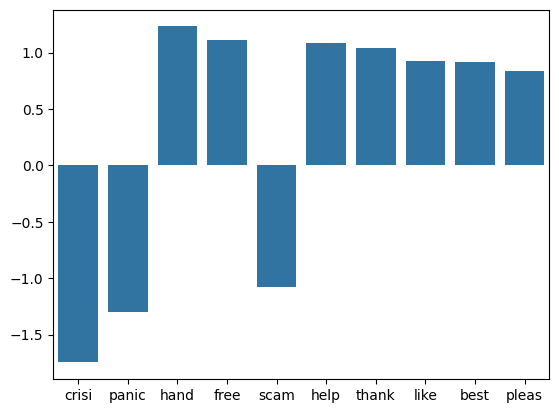

In [202]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)
x_cv = scaler.fit_transform(x_cv)
x_test_cv = scaler.transform(x_test_cv)
model_cv = LogisticRegression().fit(x_cv, y_train)
print(accuracy_score(y_test, model_cv.predict(x_test_cv)))

from seaborn import barplot

coefs_with_idx = [(idx, coef) for idx, coef in enumerate(model_cv.coef_[0])]
data = sorted(coefs_with_idx, key=lambda x: abs(x[1]), reverse=True)[:10]
names = [cv_df.get_feature_names_out()[i] for i in [i[0] for i in data]]
values = [i[1] for i in data]
barplot(y=values, x=names)
plt.show()


**Ответ:** слова частоупотребимые, но при этом имеют выраженный эмоциональный окрас.

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [ ]:
from scipy.sparse import hstack

scaler = StandardScaler(with_mean=False)

username_train = scaler.fit_transform(train['UserName'])
screenname_train = scaler.fit_transform(train['ScreenName'])

username_test = scaler.transform(test['UserName'])
screenname_test = scaler.transform(test['ScreenName'])

x_cv = hstack([x_cv, username_train, screenname_train])
x_test_cv = hstack([x_test_cv, username_test, screenname_test])

model_cv = LogisticRegression().fit(x_cv, y_train)
print(accuracy_score(y_test, model_cv.predict(x_test_cv)))

ValueError: X has 10034 features, but StandardScaler is expecting 23410 features as input.

**Ответ:** # -- YOUR ANSWER HERE --

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [ ]:
# -- YOUR CODE HERE --

**Ответ:** # -- YOUR ANSWER HERE --



Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [ ]:
# -- YOUR CODE HERE --

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

In [ ]:
# -- YOUR CODE HERE --

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

In [ ]:
# -- YOUR CODE HERE --

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [ ]:
# -- YOUR CODE HERE --

Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [ ]:
# -- YOUR CODE HERE --

**Ответ:** # -- YOUR ANSWER HERE --